In [5]:
!pip install av

In [6]:
import torch
from transformers import VideoMAEForVideoClassification, VideoMAEImageProcessor
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim
from torchvision.io import read_video
from PIL import Image
from torchvision import transforms

model = VideoMAEForVideoClassification.from_pretrained("MCG-NJU/videomae-base", num_labels=28)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

processor = VideoMAEImageProcessor.from_pretrained("MCG-NJU/videomae-base")

Some weights of VideoMAEForVideoClassification were not initialized from the model checkpoint at MCG-NJU/videomae-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
import os
from sklearn.model_selection import train_test_split

class VideoDataset(Dataset):
    def __init__(self, video_paths, labels, processor, num_frames=16, transforms=None):
        self.video_paths = video_paths
        self.labels = labels
        self.processor = processor
        self.num_frames = num_frames
        self.transforms = transforms

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        label = self.labels[idx]

        video, _, _ = read_video(video_path, pts_unit='sec')
        step = max(1, video.shape[0] // self.num_frames)
        frames = [frame.numpy() for frame in video[::step][:self.num_frames]]

        pil_frames = [Image.fromarray(frame.astype(np.uint8)) for frame in frames]

        if self.transforms:
            pil_frames = [self.transforms(frame) for frame in pil_frames]

        inputs = self.processor(images=pil_frames, return_tensors="pt")

        inputs['labels'] = torch.tensor(label, dtype=torch.long)

        return inputs


def get_video_paths_and_labels(root_dir):
    video_paths = []
    labels = []

    for label, class_folder in enumerate(sorted(os.listdir(root_dir))):
        class_path = os.path.join(root_dir, class_folder)

        if os.path.isdir(class_path):
            for video_file in sorted(os.listdir(class_path)):
                video_path = os.path.join(class_path, video_file)
                if video_path.endswith(('.mp4', '.avi', '.mov')):
                    video_paths.append(video_path)
                    labels.append(label)

    return video_paths, labels

root_dir = "/content/drive/MyDrive/Colab Notebooks/data"
video_paths, labels = get_video_paths_and_labels(root_dir)

train_video_paths, test_video_paths, train_labels, test_labels = train_test_split(video_paths, labels, test_size=0.2, random_state=101)

train_dataset = VideoDataset(train_video_paths, train_labels, processor, num_frames=16)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)

test_dataset = VideoDataset(test_video_paths, test_labels, processor, num_frames=16)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=0)

In [8]:
print(f"Labels range min={min(labels)}, max={max(labels)}")

Labels range min=0, max=27


In [9]:
import numpy as np
import torch
import time

criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)


epochs = 5
for epoch in range(epochs):
    model.train()
    start_time = time.time()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch in train_loader:
        inputs = {key: value.squeeze().to(device) for key, value in batch.items()}
        labels = inputs.pop('labels')

        optimizer.zero_grad()

        outputs = model(**inputs)
        logits = outputs.logits

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(logits, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = (correct / total) * 100
    average_loss = running_loss / len(train_loader)
    end_time = time.time()
    total_time = (end_time - start_time) / 60
    print(f"Epoch {epoch+1}/{epochs}, Accuracy: {accuracy:.2f}%, , Loss: {average_loss:.4f}, Total Time: {total_time:.4f}")

Epoch 1/5, Accuracy: 3.31%, , Loss: 3.4214, Total Time: 18.7106
Epoch 2/5, Accuracy: 3.17%, , Loss: 3.3528, Total Time: 10.2503
Epoch 3/5, Accuracy: 5.48%, , Loss: 3.2775, Total Time: 10.2820
Epoch 4/5, Accuracy: 8.07%, , Loss: 3.2102, Total Time: 10.4171
Epoch 5/5, Accuracy: 9.22%, , Loss: 3.0436, Total Time: 10.2947


In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()
correct = 0
total = 0
running_loss = 0.0
criterion = torch.nn.CrossEntropyLoss()

y_true = []
y_pred = []

with torch.no_grad():
    start_time = time.time()

    for batch in test_loader:
        inputs = {key: value.squeeze().to(device) for key, value in batch.items()}
        labels = inputs.pop('labels')

        outputs = model(**inputs)
        logits = outputs.logits

        loss = criterion(logits, labels)
        running_loss += loss.item()

        _, predicted = torch.max(logits, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = (correct / total) * 100
    end_time = time.time()
    total_time = (end_time - start_time) / 60

    print(f"Test Accuracy: {accuracy:.2f}%")
    print(f"Average Loss: {running_loss / len(test_loader):.4f}")
    print(f"Total Time for Testing: {total_time:.2f} minutes")

Test Accuracy: 1.15%
Average Loss: 3.7553
Total Time for Testing: 3.88 minutes


In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
print("\nClassification Report:")
print(classification_report(y_true, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.00      0.00      0.00         6
           2       0.00      0.00      0.00         4
           3       0.00      0.00      0.00         8
           4       0.00      0.00      0.00        10
           5       0.00      0.00      0.00         8
           6       0.00      0.00      0.00         8
           7       0.00      0.00      0.00         6
           8       0.00      0.00      0.00         4
           9       0.00      0.00      0.00         8
          10       0.00      0.00      0.00         9
          11       0.00      0.00      0.00         6
          12       0.00      0.00      0.00         5
          13       0.00      0.00      0.00         5
          14       0.00      0.00      0.00         9
          15       0.00      0.00      0.00         4
          16       0.00      0.00      0.00         5
   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


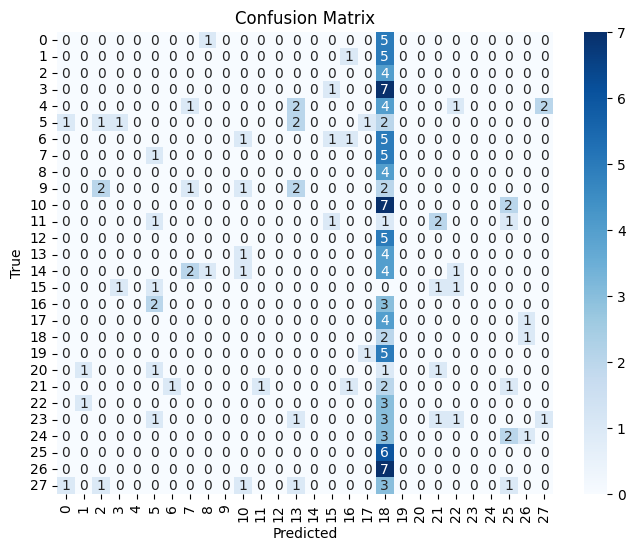

In [17]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [13]:
from google.colab import files

torch.save(model.state_dict(), "Epoch_5.pth")
files.download("Epoch_5.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>